<a href="https://colab.research.google.com/github/AyaNabih7/brain-tumor-detection/blob/main/brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Necessary Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from IPython.display import clear_output
!pip install imutils
clear_output()

In [ ]:
import cv2
import imutils
import numpy as np
import shutil
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle

%matplotlib inline

In [ ]:
# def crop_brain_contour(image):

#     # Convert the image to grayscale, and blur it slightly
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     gray = cv2.GaussianBlur(gray, (5, 5), 0)

#     # Threshold the image, then perform a series of erosions +
#     # dilations to remove any small regions of noise
#     thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
#     thresh = cv2.erode(thresh, None, iterations=2)
#     thresh = cv2.dilate(thresh, None, iterations=2)

#     # Find contours in thresholded image, then grab the largest one
#     cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     cnts = imutils.grab_contours(cnts)
#     c = max(cnts, key=cv2.contourArea)

#     # Find the extreme points
#     extLeft = tuple(c[c[:, :, 0].argmin()][0])
#     extRight = tuple(c[c[:, :, 0].argmax()][0])
#     extTop = tuple(c[c[:, :, 1].argmin()][0])
#     extBot = tuple(c[c[:, :, 1].argmax()][0])

#     # crop new image out of the original image using the four extreme points (left, right, top, bottom)
#     new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

#     return new_image

In [ ]:
def crop_brain_contour(image):

    # Convert the image to grayscale, and blur it slightly
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    # 3 X 3 X-direction kernel
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    # Filter the image using filter2D, which has inputs: (grayscale image, bit-depth, kernel)
    filtered_image_y = cv2.filter2D(gray, -1, sobel_y)
    filtered_image_x = cv2.filter2D(gray, -1, sobel_x)
    grad = cv2.addWeighted(filtered_image_x, 0.5, filtered_image_y, 0.5, 0)

    # Find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(grad.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    # Find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # crop new image out of the original image using the four extreme points (left, right, top, bottom)
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    return new_image

In [ ]:
# Function for Image preprocessing
def processDataset(dataset_src, dataset_dest):
    # Making a Copy of Dataset
    shutil.copytree(src, dest)
    for folder in os.listdir(dest):
        for (index, filen) in enumerate(os.listdir(os.path.join(dest, folder)), start = 1):
            filename = f'{folder}_brain-tumor_{index}.jpg';
            img_src = os.path.join(dest, folder, filen);
            img_des = os.path.join(dest, folder, filename);
            # Preprocess the Images
            img = cv2.imread(img_src);
            img = crop_brain_contour(img);
            img = cv2.resize(img, (240, 240), interpolation=cv2.INTER_CUBIC);
            cv2.imwrite(img_des ,img);
            os.remove(img_src);

# Source Location for Dataset
src = '/content/drive/MyDrive/brain_tumor_dataset';
# Destination Location for Dataset
dest = '/content/drive/MyDrive//BrainTumorDatasetsobel';
# Image preprocessing
processDataset(src, dest);

FileExistsError: ignored

In [ ]:
def GetDatasetSize(path):
    num_of_image = {}
    for folder in os.listdir(path):
        # Counting the Number of Files in the Folder
        num_of_image[folder] = len(os.listdir(os.path.join(path, folder)));
    return num_of_image;

path = "/content/drive/MyDrive/BrainTumorDataset"
DatasetSize = GetDatasetSize(path);
print(DatasetSize);

{'no': 98, 'yes': 155}


## Split the Dataset

#### Such that we have
* 75% for Train Data
* 15% for Validation Data
* 10% for Testing Data

In [ ]:
# Function for Creating Train / Validation / Test folders (One time use Only)

def TrainValTestSplit(root_dir, classes_dir, val_ratio = 0.15, test_ratio = 0.10):
    main_folder = '/content/drive/MyDrive/BrainTumor_Splited_Data/';

    for cls in classes_dir:
        # Creating Split Folders
        os.makedirs(main_folder + 'train' + cls)
        os.makedirs(main_folder + 'val' + cls)
        os.makedirs(main_folder + 'test' + cls)

        # Folder to copy images from
        src = root_dir + cls

        # Storing the Filenames
        allFileNames = os.listdir(src)
        np.random.seed(0)
        np.random.shuffle(allFileNames)
        # Spliting the Files in the Given ratio
        train_FileNames, val_FileNames, test_FileNames = np.split(np.array(allFileNames), [int(len(allFileNames)* (1 - (val_ratio + test_ratio))), int(len(allFileNames)* (1 - test_ratio))])

        train_FileNames = [src+'/'+ name for name in train_FileNames.tolist()]
        val_FileNames = [src+'/' + name for name in val_FileNames.tolist()]
        test_FileNames = [src+'/' + name for name in test_FileNames.tolist()]

        # Printing the Split Details
        print(cls.upper(),':')
        print('Total images: ', len(allFileNames))
        print('Training: ', len(train_FileNames))
        print('Validation: ', len(val_FileNames))
        print('Testing: ', len(test_FileNames))

        # Copy-pasting images
        for name in train_FileNames:
            shutil.copy(name, main_folder + 'train' + cls)

        for name in val_FileNames:
            shutil.copy(name, main_folder + 'val' + cls)

        for name in test_FileNames:
            shutil.copy(name, main_folder + 'test' + cls)
        print();

# Preforming Train / Validation / Test Split
root_dir = '/content/drive/MyDrive/BrainTumorDataset'              # Dataset Root Folder
classes_dir = ['/yes','/no' ]  # Classes
TrainValTestSplit(root_dir, classes_dir);

/YES :
Total images:  155
Training:  116
Validation:  23
Testing:  16

/NO :
Total images:  98
Training:  73
Validation:  15
Testing:  10



## Importing Keras for Image Classification

In [ ]:
import zipfile
import tensorflow as tf
import keras
from keras.layers import Dense,Conv2D, Flatten, MaxPool2D, Dropout
from keras.models import Sequential
from keras.preprocessing import image
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras import Model

In [ ]:
TRAIN_DIR = '/content/drive/MyDrive/BrainTumor_Splited_Data/train'
VAL_DIR = '/content/drive/MyDrive/BrainTumor_Splited_Data/val'
TEST_DIR = '/content/drive/MyDrive/BrainTumor_Splited_Data/test'

In [ ]:
def GetDatasetSize(path):
    num_of_image = {}
    for folder in os.listdir(path):
        # Counting the Number of Files in the Folder
        num_of_image[folder] = len(os.listdir(os.path.join(path, folder)));
    return num_of_image;

train_set = GetDatasetSize(TRAIN_DIR)
val_set = GetDatasetSize(VAL_DIR)
test_set = GetDatasetSize(TEST_DIR)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:17: MatplotlibDeprecationWarning: Passing the minor parameter of set_xticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.


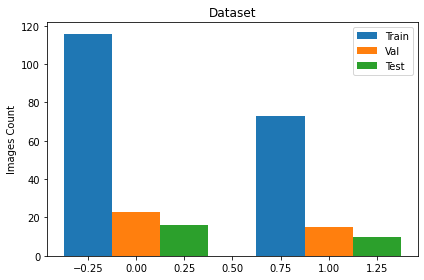

In [ ]:
labels = ['YES', 'NO']
train_list = list(train_set.values())
val_list = list(val_set.values())
test_list = list(test_set.values())

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, train_list, width, label='Train')
rects2 = ax.bar(x, val_list, width, label='Val')
rects3 = ax.bar(x + width, test_list, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Images Count')
ax.set_title('Dataset')
ax.set_xticks(x, labels)
ax.legend()


fig.tight_layout()

plt.show()

In [ ]:
train_datagen = ImageDataGenerator( rotation_range=15,
                                    width_shift_range=0.1,
                                    height_shift_range=0.1,
                                    shear_range=0.1,
                                    brightness_range=[0.5, 1.5],
                                    horizontal_flip=True,
                                    vertical_flip=True
                                    )

train_data = train_datagen.flow_from_directory(directory= TRAIN_DIR,
                                               target_size=(240,240),
                                               batch_size=32,
                                               class_mode = 'binary')

Found 189 images belonging to 2 classes.


In [ ]:
val_datagen = image.ImageDataGenerator(rescale = 1./255)

val_data = val_datagen.flow_from_directory(directory= VAL_DIR,
                                               target_size=(240,240),
                                               batch_size=32,
                                               class_mode = 'binary')

Found 38 images belonging to 2 classes.


In [ ]:
test_datagen = image.ImageDataGenerator(rescale = 1./255)

test_data = test_datagen.flow_from_directory(directory= TEST_DIR,
                                               target_size=(240,240),
                                               batch_size=32,
                                               class_mode = 'binary')

Found 26 images belonging to 2 classes.


In [ ]:
train_data.class_indices

{'no': 0, 'yes': 1}

## CNN Model

In [ ]:
# CNN Model

model = Sequential()

# Convolutional Layer with input shape (240,240,3)
model.add(Conv2D(filters=32, kernel_size= (3,3), activation= 'relu', input_shape=(240,240,3)) )

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(rate=0.25))

model.add(Flatten())
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']  )

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 238, 238, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 236, 236, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 118, 118, 32)     0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 116, 116, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 58, 58, 64)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 56, 56, 128)       7

In [ ]:
# Adding Model check point Callback

mc = ModelCheckpoint(
    filepath="./bt_cnn_best_model.hdf5",
    monitor= 'val_accuracy',
    verbose= 1,
    save_best_only= True,
    mode = 'auto'
    );

call_back = [ mc ];

In [ ]:
# Fitting the Model
cnn = model.fit(
    train_data,
    steps_per_epoch = train_data.samples//train_data.batch_size,
    epochs = 64,
    validation_data = val_data,
    validation_steps = val_data.samples//val_data.batch_size,
    callbacks = call_back
    )

Epoch 1/64
5/5 [==============================] - ETA: 0s - loss: 64.0970 - accuracy: 0.5287
Epoch 00001: val_accuracy improved from -inf to 0.40625, saving model to ./bt_cnn_best_model.hdf5
5/5 [==============================] - 41s 8s/step - loss: 64.0970 - accuracy: 0.5287 - val_loss: 0.7019 - val_accuracy: 0.4062
Epoch 2/64
5/5 [==============================] - ETA: 0s - loss: 3.6185 - accuracy: 0.4650
Epoch 00002: val_accuracy improved from 0.40625 to 0.43750, saving model to ./bt_cnn_best_model.hdf5
5/5 [==============================] - 37s 7s/step - loss: 3.6185 - accuracy: 0.4650 - val_loss: 0.6936 - val_accuracy: 0.4375
Epoch 3/64
5/5 [==============================] - ETA: 0s - loss: 0.9482 - accuracy: 0.5159
Epoch 00003: val_accuracy did not improve from 0.43750
5/5 [==============================] - 37s 7s/step - loss: 0.9482 - accuracy: 0.5159 - val_loss: 0.6935 - val_accuracy: 0.3750
Epoch 4/64
5/5 [==============================] - ETA: 0s - loss: 0.7031 - accuracy: 0.

UnknownError: ignored

In [ ]:
# Loading the Best Fit Model
model = load_model("./bt_cnn_best_model.hdf5")

In [ ]:
# Checking the Accuracy of the Model
accuracy_cnn = model.evaluate_generator(generator= test_data)[1]
print(f"The accuracy of the model is = {accuracy_cnn*100} %")

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  


The accuracy of the model is = 61.538463830947876 %


In [ ]:
cnn.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

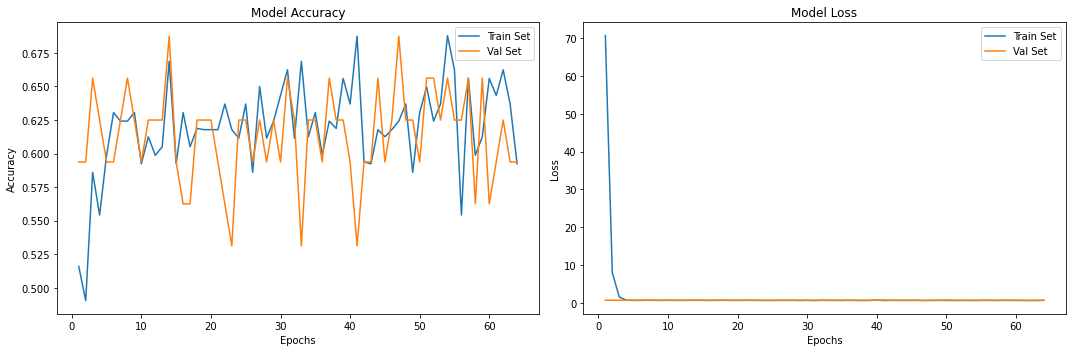

In [ ]:
# Plot model performance
acc = cnn.history['accuracy']
val_acc = cnn.history['val_accuracy']
loss = cnn.history['loss']
val_loss = cnn.history['val_loss']
epochs_range = range(1, len(cnn.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

## VGG16 Model

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16

model_VGG = VGG16(
    weights='imagenet',
    input_shape = (240, 240, 3), # Shape of our images
    include_top = False  # Leave out the last fully connected layer
    )

58900480/58889256 [==============================] - 0s 0us/step


In [ ]:
vgg16 = Sequential()
vgg16.add(model_VGG)
vgg16.add(layers.Dropout(0.3))
vgg16.add(layers.Flatten())
vgg16.add(layers.Dropout(0.5))
vgg16.add(layers.Dense(1, activation='sigmoid'))

vgg16.layers[0].trainable = False

vgg16.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    metrics=['accuracy']
)

vgg16.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
dropout_2 (Dropout)          (None, 7, 7, 512)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 25088)             0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 25089     
Total params: 14,739,777
Trainable params: 25,089
Non-trainable params: 14,714,688
_________________________________________________________________


In [ ]:
# Adding Model check point Callback

mc = ModelCheckpoint(
    filepath="./bt_vgg_best_model.hdf5",
    monitor= 'val_accuracy',
    verbose= 1,
    save_best_only= True,
    mode = 'auto'
    );

call_back = [ mc ];

In [ ]:
vgg = vgg16.fit(
    train_data,
    steps_per_epoch = train_data.samples//train_data.batch_size,
    epochs = 64,
    validation_data = val_data,
    validation_steps = val_data.samples//val_data.batch_size,
    callbacks=call_back
)

Epoch 1/64
5/5 [==============================] - 9s 1s/step - loss: 8.8629 - accuracy: 0.4713 - val_loss: 0.6138 - val_accuracy: 0.5938

Epoch 00001: val_accuracy improved from -inf to 0.59375, saving model to ./bt_vgg_best_model.hdf5
Epoch 2/64
5/5 [==============================] - 2s 501ms/step - loss: 6.1409 - accuracy: 0.5796 - val_loss: 0.5844 - val_accuracy: 0.6875

Epoch 00002: val_accuracy improved from 0.59375 to 0.68750, saving model to ./bt_vgg_best_model.hdf5
Epoch 3/64
5/5 [==============================] - 3s 499ms/step - loss: 4.7928 - accuracy: 0.6242 - val_loss: 0.5768 - val_accuracy: 0.7188

Epoch 00003: val_accuracy improved from 0.68750 to 0.71875, saving model to ./bt_vgg_best_model.hdf5
Epoch 4/64
5/5 [==============================] - 3s 508ms/step - loss: 4.9025 - accuracy: 0.6938 - val_loss: 0.5839 - val_accuracy: 0.6250

Epoch 00004: val_accuracy did not improve from 0.71875
Epoch 5/64
5/5 [==============================] - 2s 488ms/step - loss: 4.4812 - acc

In [ ]:
# Loading the Best Fit Model
modelVGG = load_model("./bt_vgg_best_model.hdf5")

In [ ]:
# Checking the Accuracy of the Model
accuracy_vgg = modelVGG.evaluate_generator(generator= test_data)[1]
print(f"The accuracy of the model is = {accuracy_vgg*100} %")

The accuracy of the model is = 69.2307710647583 %


In [ ]:
vgg.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

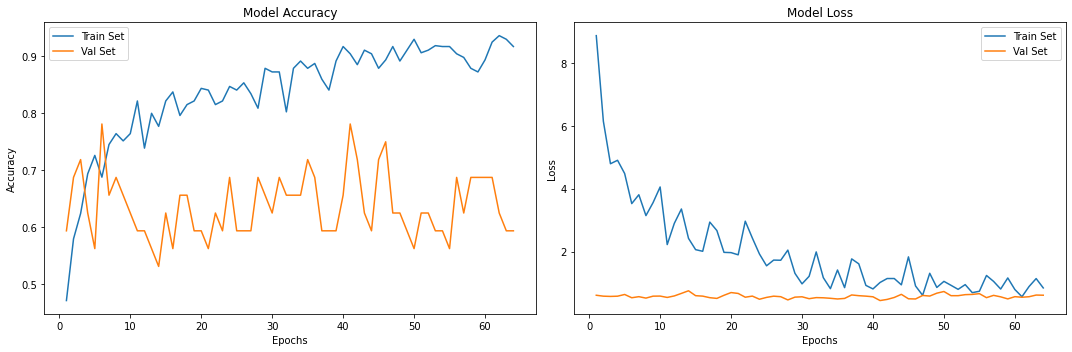

In [ ]:
# Plot model performance
acc = vgg.history['accuracy']
val_acc = vgg.history['val_accuracy']
loss = vgg.history['loss']
val_loss = vgg.history['val_loss']
epochs_range = range(1, len(vgg.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

## Inceptionv3 Model

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

base_model = InceptionV3(input_shape = (240, 240, 3),
                         include_top = False,
                         weights = 'imagenet')

87924736/87910968 [==============================] - 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

x = layers.Flatten()(base_model.output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# Add a final sigmoid layer with 1 node for classification output
x = layers.Dense(1, activation='sigmoid')(x)

model_incep = tf.keras.models.Model(base_model.input, x)

model_incep.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001),
                    loss = 'binary_crossentropy',
                    metrics = ['accuracy'])

In [ ]:
# Adding Model check point Callback

mc = ModelCheckpoint(
    filepath="./ct_incep_best_model.hdf5",
    monitor= 'val_accuracy',
    verbose= 1,
    save_best_only= True,
    mode = 'auto'
    );

call_back = [mc];

In [ ]:
# Fitting the Model
incep = model_incep.fit(
    train_data,
    steps_per_epoch = train_data.samples//train_data.batch_size,
    epochs = 64,
    validation_data = val_data,
    validation_steps = val_data.samples//val_data.batch_size,
    callbacks = call_back
    )

Epoch 1/64
5/5 [==============================] - 8s 836ms/step - loss: 234.5365 - accuracy: 0.4395 - val_loss: 3.2503 - val_accuracy: 0.5312

Epoch 00001: val_accuracy improved from -inf to 0.53125, saving model to ./ct_incep_best_model.hdf5
Epoch 2/64
5/5 [==============================] - 3s 540ms/step - loss: 47.3090 - accuracy: 0.5796 - val_loss: 3.2796 - val_accuracy: 0.4062

Epoch 00002: val_accuracy did not improve from 0.53125
Epoch 3/64
5/5 [==============================] - 3s 557ms/step - loss: 34.6616 - accuracy: 0.5159 - val_loss: 1.6102 - val_accuracy: 0.6250

Epoch 00003: val_accuracy improved from 0.53125 to 0.62500, saving model to ./ct_incep_best_model.hdf5
Epoch 4/64
5/5 [==============================] - 3s 525ms/step - loss: 22.5146 - accuracy: 0.6438 - val_loss: 2.1423 - val_accuracy: 0.4375

Epoch 00004: val_accuracy did not improve from 0.62500
Epoch 5/64
5/5 [==============================] - 3s 588ms/step - loss: 20.2468 - accuracy: 0.5796 - val_loss: 1.7245 

In [ ]:
# Loading the Best Fit Model
inceptionv3_model = load_model("./ct_incep_best_model.hdf5")

In [ ]:
# Checking the Accuracy of the Model
accuracy_incep = inceptionv3_model.evaluate_generator(generator= test_data)[1]
print(f"The accuracy of the model is = {accuracy_incep*100} %")

The accuracy of the model is = 61.538463830947876 %


In [ ]:
incep.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

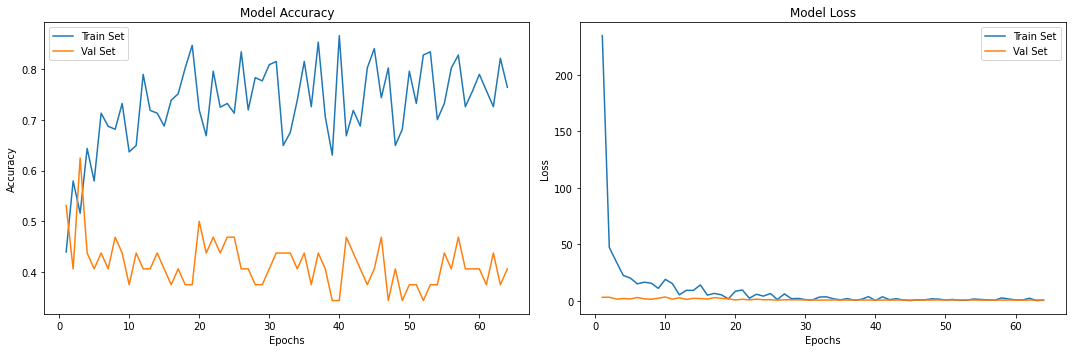

In [ ]:
# Plot model performance
acc = incep.history['accuracy']
val_acc = incep.history['val_accuracy']
loss = incep.history['loss']
val_loss = incep.history['val_loss']
epochs_range = range(1, len(incep.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

## RestNet50 Model

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(input_shape=(240, 240,3),
                      include_top=False,
                      weights="imagenet")

94781440/94765736 [==============================] - 0s 0us/step


In [ ]:
model_resnet = Sequential()
model_resnet.add(base_model)
model_resnet.add(layers.Dropout(0.3))
model_resnet.add(layers.Flatten())
model_resnet.add(layers.Dropout(0.5))
model_resnet.add(layers.Dense(1, activation='sigmoid'))

model_resnet.layers[0].trainable = False

In [ ]:
model_resnet.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
                     loss = 'binary_crossentropy',
                     metrics = ['accuracy'])

model_resnet.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 8, 8, 2048)        23587712  
_________________________________________________________________
dropout_5 (Dropout)          (None, 8, 8, 2048)        0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 131072)            0         
_________________________________________________________________
dropout_6 (Dropout)          (None, 131072)            0         
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 131073    
Total params: 23,718,785
Trainable params: 131,073
Non-trainable params: 23,587,712
_________________________________________________________________


In [ ]:
# Adding Model check point Callback

mc = ModelCheckpoint(
    filepath="./ct_resnet_best_model.hdf5",
    monitor= 'val_accuracy',
    verbose= 1,
    save_best_only= True,
    mode = 'auto'
    );

call_back = [mc];

In [ ]:
# Fitting the Model
resnet = model_resnet.fit(
    train_data,
    steps_per_epoch = train_data.samples//train_data.batch_size,
    epochs = 64,
    validation_data = val_data,
    validation_steps = val_data.samples//val_data.batch_size,
    callbacks = call_back
    )

Epoch 1/64
5/5 [==============================] - 6s 753ms/step - loss: 2.0283 - accuracy: 0.4522 - val_loss: 0.7986 - val_accuracy: 0.6562

Epoch 00001: val_accuracy improved from -inf to 0.65625, saving model to ./ct_resnet_best_model.hdf5


/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


Epoch 2/64
5/5 [==============================] - 3s 551ms/step - loss: 1.8738 - accuracy: 0.5223 - val_loss: 1.0607 - val_accuracy: 0.5938

Epoch 00002: val_accuracy did not improve from 0.65625
Epoch 3/64
5/5 [==============================] - 2s 492ms/step - loss: 1.1463 - accuracy: 0.6688 - val_loss: 1.1184 - val_accuracy: 0.6250

Epoch 00003: val_accuracy did not improve from 0.65625
Epoch 4/64
5/5 [==============================] - 3s 503ms/step - loss: 1.1166 - accuracy: 0.6688 - val_loss: 1.0868 - val_accuracy: 0.5938

Epoch 00004: val_accuracy did not improve from 0.65625
Epoch 5/64
5/5 [==============================] - 2s 498ms/step - loss: 0.8206 - accuracy: 0.7516 - val_loss: 0.9918 - val_accuracy: 0.5938

Epoch 00005: val_accuracy did not improve from 0.65625
Epoch 6/64
5/5 [==============================] - 3s 664ms/step - loss: 1.0429 - accuracy: 0.7070 - val_loss: 1.0057 - val_accuracy: 0.5938

Epoch 00006: val_accuracy did not improve from 0.65625
Epoch 7/64
5/5 [====

In [ ]:
# Loading the Best Fit Model
resnet_model = load_model("./ct_resnet_best_model.hdf5")

In [ ]:
# Checking the Accuracy of the Model
accuracy_resnet = resnet_model.evaluate_generator(generator= test_data)[1]
print(f"The accuracy of the model is = {accuracy_resnet*100} %")

The accuracy of the model is = 61.538463830947876 %


In [ ]:
resnet.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

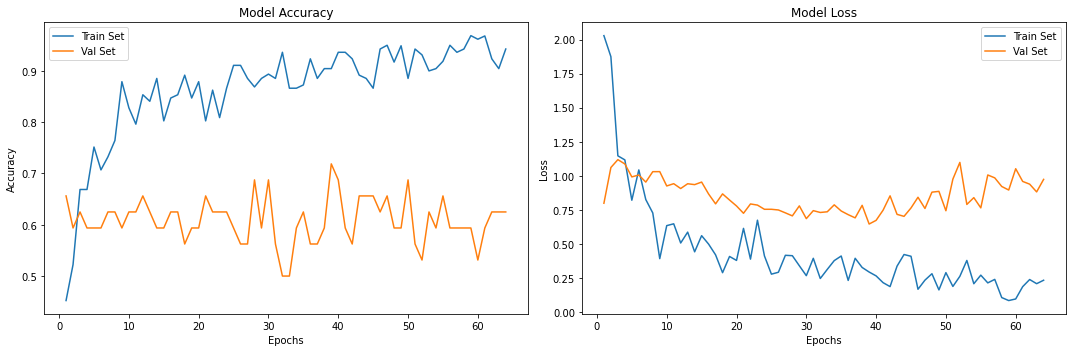

In [ ]:
# Plot model performance
acc = resnet.history['accuracy']
val_acc = resnet.history['val_accuracy']
loss = resnet.history['loss']
val_loss = resnet.history['val_loss']
epochs_range = range(1, len(resnet.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

## Comparison

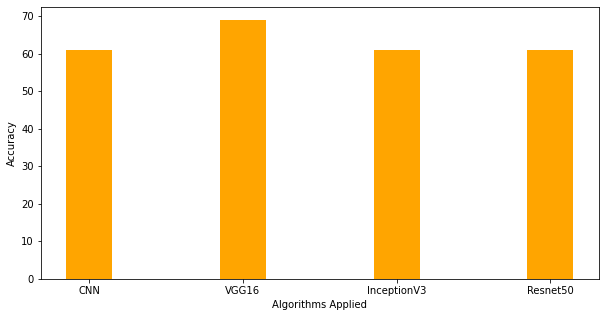

In [ ]:
algos = ['CNN', 'VGG16', 'InceptionV3', 'Resnet50']
accuracy = [accuracy_cnn, accuracy_vgg, accuracy_incep, accuracy_resnet]
accuracy = np.floor([i * 100 for i in accuracy])

fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(algos, accuracy, color ='orange', width = 0.3)

plt.xlabel("Algorithms Applied")
plt.ylabel("Accuracy")
plt.show()

### Predictions

In [ ]:
def brainTumorPrediction(path,Model):
    # Loading Image
    img = image.load_img(path, target_size=(240,240))
    # Normalizing Image
    norm_img = image.img_to_array(img)/255
    # Converting Image to Numpy Array
    input_arr_img = np.array([norm_img])
    # Getting Predictions
    pred = (Model.predict(input_arr_img) > 0.5).astype(int)[0][0]
    # Printing Model Prediction
    if pred == 0:
        print("No Brain tumor")
    else:
        print("Brain Tumor")

In [ ]:
path = "../input/brain-mri-images-for-brain-tumor-detection/yes/Y10.jpg"
brainTumorPrediction(path,modelVGG)

Brain Tumor
